# Likelihood and MLE

## Math Formation

The target variable for this project is binary, where default is 1 and no default is 0. In this secion, we will use the logistic regression to model the likelihood of default. For a client with x features, the model formula is:

$$P(Y=1 \mid \mathbf{x}) = \sigma(\mathbf{x}^T\boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^T\boldsymbol{\beta}}}$$

where $\sigma(\cdot)$ is the sigmoid function and $\boldsymbol{\beta}$ is the vector of coefficients to be estimated.


Given the n independent observations, we can formulate a likelihood function like this: 

$$L(\boldsymbol{\beta}) = \prod_{i=1}^{n} \sigma(\mathbf{x}_i^T\boldsymbol{\beta})^{y_i} \left(1 - \sigma(\mathbf{x}_i^T\boldsymbol{\beta})\right)^{1-y_i}$$

After taking the log, it will look like this: 

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log \sigma(\mathbf{x}_i^T\boldsymbol{\beta}) + (1-y_i) \log\left(1 - \sigma(\mathbf{x}_i^T\boldsymbol{\beta})\right) \right]$$

## Code

### Load and Prepare

In [3]:
!pip install statsmodels

  Using cached statsmodels-0.14.6-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.4 MB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/processed/cleaned_default_data.csv")
df.columns = df.columns.str.strip()

target = 'default payment next month'
feature_cols = [col for col in df.columns if col != target]

X = df[feature_cols].values
y = df[target].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

### MLE with statsmodel

In [13]:
X_sm = sm.add_constant(X_scaled_df) # Add constant term for intercept
logit_model = sm.Logit(y, X_sm) # Fit the logistic regression model using MLE
result = logit_model.fit(method='newton', maxiter=200)
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.464682
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                29965
Model:                          Logit   Df Residuals:                    29941
Method:                           MLE   Df Model:                           23
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1207
Time:                        15:23:11   Log-Likelihood:                -13924.
converged:                       True   LL-Null:                       -15836.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4653      0.017    -88.259      0.000      -1.498      -1.433
LIMIT_BAL     -0.1003      0.

The model achieved a log-likelihood of −13,924 compared to −15,836 for the intercept-only null model, meaning that the 23 features provide substantial improvement to the model. McFadden's Pseudo R² of 0.121 means that the uncertainty of the model was reduced by approximately 12%, which is considered good fit for behavioral financial data and consistent with published credit scoring literature. 

### MLE Coefficients

In [16]:
mle_coefficients = result.params
conf_int = result.conf_int()

print("MLE Coefficients for top features:")
summary_df = pd.DataFrame({
    "Coefficient": mle_coefficients,
    "CI Lower": conf_int[0],
    "CI Upper": conf_int[1],
    "p-value": result.pvalues
}).drop(index="const").sort_values(by="Coefficient", key=abs, ascending=False)

print(summary_df.head(10))

MLE Coefficients for top features:
           Coefficient  CI Lower  CI Upper        p-value
PAY_0         0.649681  0.610644  0.688719  2.245617e-233
BILL_AMT1    -0.404705 -0.568729 -0.240681   1.325279e-06
PAY_AMT1     -0.225902 -0.300783 -0.151020   3.363454e-09
PAY_AMT2     -0.221682 -0.316339 -0.127025   4.429840e-06
BILL_AMT2     0.167750 -0.042198  0.377699   1.173427e-01
LIMIT_BAL    -0.100254 -0.140197 -0.060311   8.680944e-07
PAY_2         0.098356  0.050996  0.145716   4.693938e-05
BILL_AMT3     0.094741 -0.085141  0.274623   3.019394e-01
PAY_3         0.085859  0.032876  0.138843   1.492703e-03
EDUCATION    -0.080454 -0.112951 -0.047958   1.219103e-06


**Significant Features (p < 0.05)**

| Feature | β̂ (MLE) | CI | p-value | Interpretation |
|---|---|---|---|---|
| `PAY_0` | +0.6497 | [+0.611, +0.689] | 2.25e-233 | Strongest predictor (recent payment delay increases default odds by e^0.650 ≈ 1.92) |
| `BILL_AMT1` | -0.4047 | [-0.569, -0.241] | 1.33e-06 | Higher recent bill → lower default odds |
| `PAY_AMT1` | -0.2259 | [-0.301, -0.151] | 3.36e-09 | Higher recent payment → lower default risk |
| `PAY_AMT2` | -0.2217 | [-0.316, -0.127] | 4.43e-06 | Same protective pattern one month prior |
| `LIMIT_BAL` | -0.1003 | [-0.140, -0.060] | 8.68e-07 | Higher credit limit → lower default odds |

**Insignificant Features (p > 0.05, CI crosses zero)**

| Feature | β̂ (MLE) | CI | p-value | Note |
|---|---|---|---|---|
| `PAY_6` | +0.0088 | [-0.041, +0.059] | 0.730 | Oldest payment delay |
| `BILL_AMT4` | -0.0115 | [-0.182, +0.159] | 0.894 | Effectively zero effect |
| `BILL_AMT5` | +0.0377 | [-0.143, +0.218] | 0.683 | No predictive value |
| `PAY_4` | +0.0276 | [-0.030, +0.085] | 0.344 | Recency effect fades beyond 3 months |


The MLE for PAY_0 is the largest and most significant coefficient that corresponds to a 92% increase in the odds of default per unit increase in payment delay. Features beyond a 3-month lag (PAY_4–PAY_6, BILL_AMT2–6) are largely insignificant, suggesting that recent behavior has more influence over credit risk assessment. In addition, the CIs from the inverse Fisher information matrix confirm that PAY_0 is the only feature whose confidence interval is entirely far from zero, while older bill statement amounts (BILL_AMT2, BILL_AMT3) are statistically indistinguishable from zero. 

### Log-likelihood 

In [18]:
from scipy.special import expit

# Function to compute log-likelihood for a given beta_pay0 value
def log_likelihood(beta_pay0, X, y, mle_params, idx):
    params = mle_params.copy()
    params[idx] = beta_pay0
    logits = X @ params
    ll = np.sum(y * np.log(expit(logits)) + (1 - y) * np.log(1 - expit(logits)))
    return ll

# Extract necessary data for likelihood computation
X_np = X_sm.values
y_np = y
mle_vals = result.params.values
pay0_idx = list(X_sm.columns).index("PAY_0")

# Sweep beta_pay0 around its MLE value
mle_pay0 = mle_vals[pay0_idx]
beta_range = np.linspace(mle_pay0 - 1, mle_pay0 + 1, 300)
ll_values = [log_likelihood(beta, X_np, y_np, mle_vals, pay0_idx) for beta in beta_range]

# Get CI bounds for beta_pay0
ci_lower = conf_int.loc["PAY_0", 0]
ci_upper = conf_int.loc["PAY_0", 1]


### Plot

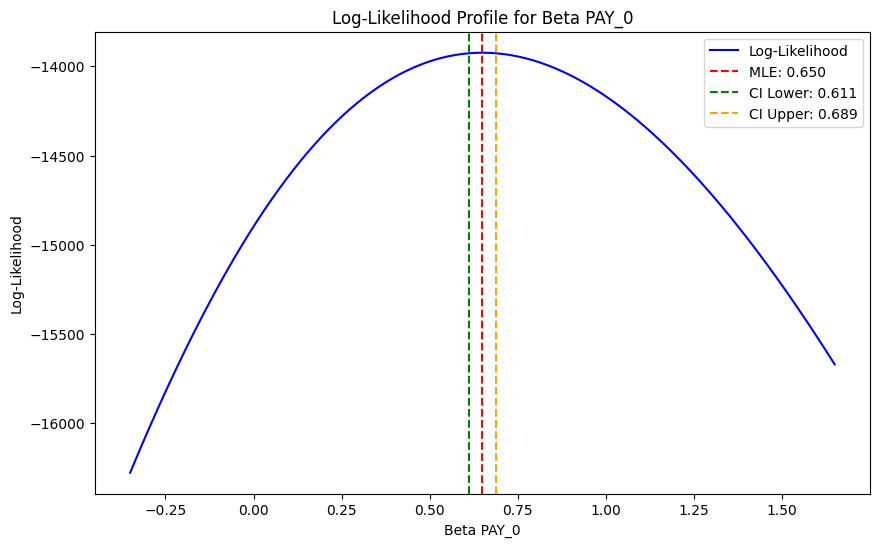

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beta_range, ll_values, label='Log-Likelihood', color='blue')
ax.axvline(mle_pay0, color='red', linestyle='--', label=f'MLE: {mle_pay0:.3f}')
ax.axvline(ci_lower, color='green', linestyle='--', label=f'CI Lower: {ci_lower:.3f}')
ax.axvline(ci_upper, color='orange', linestyle='--', label=f'CI Upper: {ci_upper:.3f}')
ax.set_xlabel('Beta PAY_0')
ax.set_ylabel('Log-Likelihood')
ax.set_title('Log-Likelihood Profile for Beta PAY_0')
ax.legend()
plt.show()

### Summary

In [21]:
ll_at_mle = log_likelihood(mle_pay0, X_np, y_np, mle_vals, pay0_idx)
print(f"MLE for PAY_0: {mle_pay0:.4f}")
print(f"Log-likelihood at MLE: {ll_at_mle:.2f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

MLE for PAY_0: 0.6497
Log-likelihood at MLE: -13924.19
95% CI: [0.6106, 0.6887]


The log-likelihood surface for βPAY_0​ is strictly concave with a unique maximum at β^=0.6497, confirming numerical convergence to the global MLE. The 95% confidence interval [0.6106, 0.6887] derived from the Fisher information matrix lies entirely above zero, providing strong evidence that recent payment delay significantly increases the log-odds of default.